Setup

In [1]:
# If on Colab, mount Drive first
from google.colab import drive
drive.mount('/content/drive')

# Then clone/pull repo (your usual cells)
import os
REPO = "LaneDetection"
if not os.path.exists(f"/content/{REPO}"):
    !git clone https://github.com/abdullahtapanci/LaneDetection.git /content/{REPO}
else:
    !cd /content/{REPO} && git pull
%cd /content/{REPO}

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Already up to date.
/content/LaneDetection


İmport and load model

In [2]:
import os, time, cv2, torch
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import display, clear_output

import src.config as cfg
from src.models.lanenet import LaneNet
from src.postprocess import my_postprocess, draw_lanes

device = "cuda" if torch.cuda.is_available() else "cpu"
print("device:", device)

# Load model + checkpoint
CKPT_PATH = "/content/drive/MyDrive/Lane_Detection_Project/checkpoints/best.pt"
# CKPT_PATH = "checkpoints/best.pt"   # local

model = LaneNet(embedding_dim=4).to(device)
ckpt  = torch.load(CKPT_PATH, map_location=device)
model.load_state_dict(ckpt['model_state_dict'])
model.eval()
print(f"Loaded checkpoint from epoch {ckpt['epoch']}")

device: cpu
Loaded checkpoint from epoch 5


preprocess frames

In [3]:
# Same preprocessing as src/data/transforms.py, but for an in-memory frame
_IMNET_MEAN = np.array([0.485, 0.456, 0.406], dtype=np.float32)
_IMNET_STD  = np.array([0.229, 0.224, 0.225], dtype=np.float32)

def preprocess_frame(frame_bgr, target_w=cfg.IMAGE_WIDTH, target_h=cfg.IMAGE_HEIGHT):
    """frame_bgr: (Ho, Wo, 3) uint8 from cv2.VideoCapture.
       Returns: tensor (1, 3, H, W) ready for the model + the resized RGB frame."""
    frame = cv2.resize(frame_bgr, (target_w, target_h))
    frame_rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
    f = frame_rgb.astype(np.float32) / 255.0
    f = (f - _IMNET_MEAN) / _IMNET_STD
    t = torch.from_numpy(f).permute(2, 0, 1).unsqueeze(0)   # (1, 3, H, W)
    return t, frame_rgb

This part is for image input

binary_logits shape=(2, 256, 512)  range=[-6.14, 8.08]
embedding     shape=(4, 256, 512)     range=[-10.30, 9.01]
Pred lane pixels: 7,907 / 131,072 (6.03%)
Detected 3 lanes
  Lane 0: poly=[ 6.00000e-03 -3.67800e+00  6.44399e+02]  y_range=(142, 251)  n_pixels=3350
  Lane 1: poly=[-1.00000e-02  4.93800e+00 -1.95368e+02]  y_range=(134, 242)  n_pixels=3663
  Lane 2: poly=[-3.00000e-03  3.92200e+00 -1.70249e+02]  y_range=(138, 194)  n_pixels=654


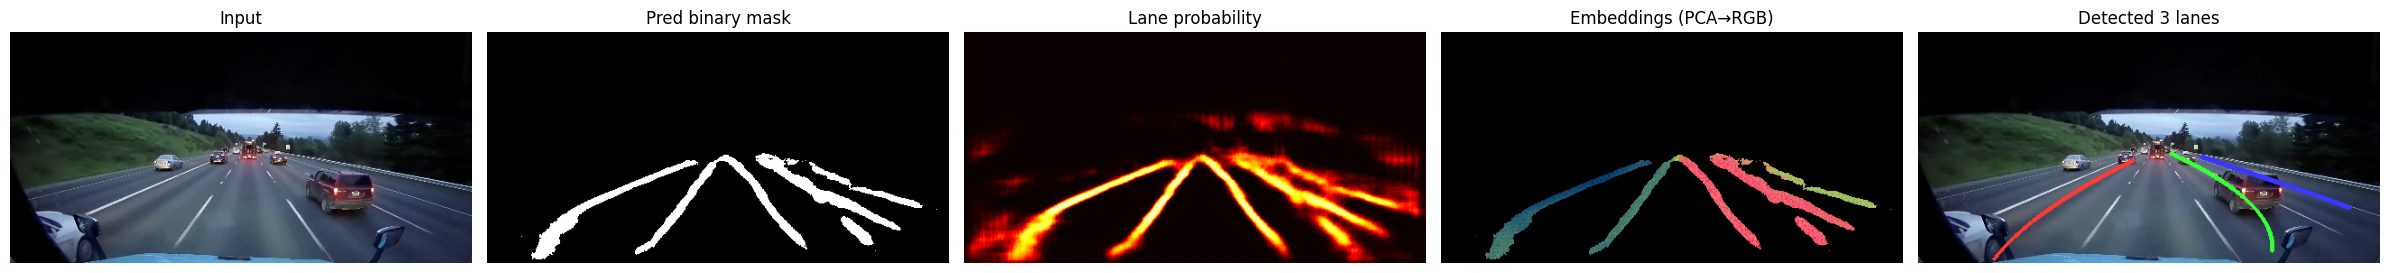

In [ ]:
from sklearn.decomposition import PCA

IMAGE_PATH = "/content/drive/MyDrive/Lane_Detection_Project/sampleImages/testImage1.png"
# IMAGE_PATH = "samples/test.jpg"   # local

# Hyperparams
EPS, MIN_SAMPLES, MIN_PIXELS, BANDWIDTH = 0.2, 50, 100, 1.0

# --- Read image ---
frame_bgr = cv2.imread(IMAGE_PATH)
assert frame_bgr is not None, f"Cannot open image: {IMAGE_PATH}"

# --- Preprocess + run model ---
x, frame_rgb = preprocess_frame(frame_bgr)
with torch.no_grad():
    binary_logits, embedding = model(x.to(device))

# --- Postprocess ---
binary_np = binary_logits.squeeze(0).cpu().numpy()    # (2, H, W)
emb_np    = embedding.squeeze(0).cpu().numpy()         # (D, H, W)

lanes = my_postprocess(binary_np, emb_np,
                       eps=EPS, min_samples=MIN_SAMPLES,
                       poly_degree=2, min_pixels=MIN_PIXELS, bandwidth=BANDWIDTH, clustering_algorithm='meanshift')

# --- Pull intermediates for visualization ---
binary_pred = binary_np.argmax(axis=0).astype(np.uint8)                # (H, W)
binary_prob = torch.softmax(binary_logits, dim=1)[0, 1].cpu().numpy()  # lane prob

# Stats
print(f"binary_logits shape={binary_np.shape}  range=[{binary_np.min():.2f}, {binary_np.max():.2f}]")
print(f"embedding     shape={emb_np.shape}     range=[{emb_np.min():.2f}, {emb_np.max():.2f}]")
print(f"Pred lane pixels: {binary_pred.sum():,} / {binary_pred.size:,} "
      f"({100*binary_pred.mean():.2f}%)")
print(f"Detected {len(lanes)} lanes")
for i, l in enumerate(lanes):
    print(f"  Lane {i}: poly={l['poly'].round(3)}  y_range={l['y_range']}  "
          f"n_pixels={len(l['pixels'])}")

# --- Embedding PCA → RGB (only at predicted lane pixels) ---
D, H, W = emb_np.shape
emb_flat = emb_np.reshape(D, -1).T
lane_mask = binary_pred.astype(bool).flatten()
emb_rgb = np.zeros((H * W, 3), dtype=np.float32)
if lane_mask.sum() >= 3:
    pca = PCA(n_components=3).fit_transform(emb_flat[lane_mask])
    pca -= pca.min(axis=0); pca /= pca.max(axis=0) + 1e-8
    emb_rgb[lane_mask] = pca
emb_rgb = emb_rgb.reshape(H, W, 3)

# --- Draw lanes ---
annotated = draw_lanes(frame_rgb.copy(), lanes)

# --- 5-panel visualization ---
fig, axes = plt.subplots(1, 5, figsize=(24, 5))
axes[0].imshow(frame_rgb);                                axes[0].set_title("Input")
axes[1].imshow(binary_pred, cmap="gray");                 axes[1].set_title("Pred binary mask")
axes[2].imshow(binary_prob, cmap="hot", vmin=0, vmax=1);  axes[2].set_title("Lane probability")
axes[3].imshow(emb_rgb);                                  axes[3].set_title("Embeddings (PCA→RGB)")
axes[4].imshow(annotated);                                axes[4].set_title(f"Detected {len(lanes)} lanes")
for a in axes: a.axis("off")
plt.tight_layout(); plt.show()

Real time loop

KeyboardInterrupt: 

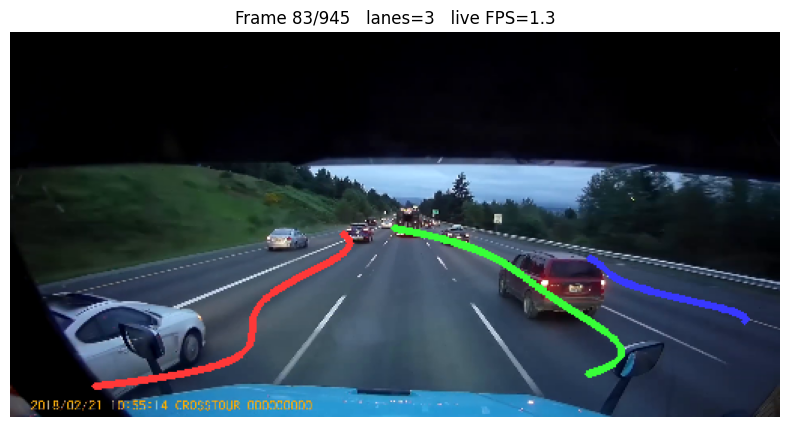

In [12]:
VIDEO_PATH = "/content/drive/MyDrive/Lane_Detection_Project/sampleVideos/testVideo1.mp4"
# VIDEO_PATH = "samples/highway.mp4"   # local

# Postprocess hyperparameters — tune these per your trained model
EPS         = 0.5
MIN_SAMPLES = 50
MIN_PIXELS  = 100

cap = cv2.VideoCapture(VIDEO_PATH)
assert cap.isOpened(), f"Cannot open video: {VIDEO_PATH}"
total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
fps_in       = cap.get(cv2.CAP_PROP_FPS)
print(f"Video: {total_frames} frames, source FPS ~{fps_in:.1f}")

fig, ax = plt.subplots(figsize=(10, 5))
ax.axis("off")

frame_idx = 0
t_start = time.time()

with torch.no_grad():
    while True:
        ok, frame_bgr = cap.read()
        if not ok:
            break

        # Preprocess + model
        x, frame_rgb = preprocess_frame(frame_bgr)
        x = x.to(device)
        binary_logits, embedding = model(x)

        # Postprocess (numpy)
        binary_np = binary_logits.squeeze(0).cpu().numpy()
        emb_np    = embedding.squeeze(0).cpu().numpy()
        lanes = my_postprocess(binary_np, emb_np,
                            eps=EPS, min_samples=MIN_SAMPLES, poly_degree=4,
                            min_pixels=MIN_PIXELS)

        # Draw on the resized RGB frame
        annotated = draw_lanes(frame_rgb.copy(), lanes)

        # Update the matplotlib figure in place
        ax.clear(); ax.axis("off")
        elapsed = time.time() - t_start
        live_fps = (frame_idx + 1) / elapsed if elapsed > 0 else 0
        ax.imshow(annotated)
        ax.set_title(f"Frame {frame_idx+1}/{total_frames}   "
                     f"lanes={len(lanes)}   live FPS={live_fps:.1f}")
        clear_output(wait=True)
        display(fig)

        frame_idx += 1

cap.release()
plt.close(fig)
print("Done.")

Save the file instead of lve stream

In [ ]:
INPUT  = "/content/drive/MyDrive/Lane_Detection_Project/samples/highway.mp4"
OUTPUT = "/content/lanes_annotated.mp4"

cap = cv2.VideoCapture(INPUT)
fps_in = cap.get(cv2.CAP_PROP_FPS) or 30.0

writer = None
with torch.no_grad():
    while True:
        ok, frame_bgr = cap.read()
        if not ok: break
        x, frame_rgb = preprocess_frame(frame_bgr)
        x = x.to(device)
        binary_logits, embedding = model(x)
        binary_np = binary_logits.squeeze(0).cpu().numpy()
        emb_np    = embedding.squeeze(0).cpu().numpy()
        lanes = postprocess(binary_np, emb_np, eps=EPS,
                            min_samples=MIN_SAMPLES, min_pixels=MIN_PIXELS)
        annotated = draw_lanes(frame_rgb.copy(), lanes)
        annotated_bgr = cv2.cvtColor(annotated, cv2.COLOR_RGB2BGR)

        if writer is None:
            h, w = annotated_bgr.shape[:2]
            writer = cv2.VideoWriter(OUTPUT, cv2.VideoWriter_fourcc(*'mp4v'),
                                     fps_in, (w, h))
        writer.write(annotated_bgr)

cap.release()
if writer: writer.release()
print(f"Saved to {OUTPUT}")

Watch video

In [ ]:
from IPython.display import Video
Video(OUTPUT, embed=True, width=800)